In [1]:
# https://www.kaggle.com/competitions/playground-series-s6e9

import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from IPython import display

RANDOM_STATE = 42
N_SPLITS = 5

BAR_COLOR = "tab:blue"
LINE_COLOR = "tab:orange"
ACCENT_COLOR = "tab:purple"
GOOD_COLOR = "tab:green"

DATA_DIR = Path(kagglehub.competition_download("playground-series-s6e9"))
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

TARGET = 'Will_Buy_EV'
ID_COLUMN = 'id'

assert train.drop(columns=[TARGET]).columns.tolist() == test.columns.tolist(), 'Train and test columns do not match'
assert sample_submission[ID_COLUMN].equals(test[ID_COLUMN]), 'Test and sample submission IDs do not match'
print(f'Train shape: {train.shape}, Test shape: {test.shape}')
print(f'Target distribution:\n{train[TARGET].value_counts(normalize=True)}')



Train shape: (668665, 15), Test shape: (286571, 14)
Target distribution:
Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64


In [2]:
print(f'Null values in train: {train.isna().sum().sum()}')
print(f'Null values in test : {test.isna().sum().sum()}')

Null values in train: 0
Null values in test : 0


In [3]:
def feature_overview(df: pd.DataFrame, cols: list[str])->pd.DataFrame:
    rows = []
    for col in cols:
        rows.append({
            'feature': col,
            'dtype': str(df[col].dtype),
            'unique': df[col].nunique(),
            'min': df[col].min(numeric_only=True),
            'max': df[col].max(numeric_only=True),
            'missing': df[col].isna().sum(),
            'missing_%': df[col].isna().mean()
        })
    return pd.DataFrame(rows).sort_values(['dtype', 'unique']).reset_index(drop=True)

overview = feature_overview(train, train.drop(ID_COLUMN, axis=1).columns.to_list())
overview.style.background_gradient(subset=['missing', 'missing_%'], cmap='Blues').format({'missing_%': '{:.2f}'})


,feature,dtype,unique,min,max,missing,missing_%
0,Environmental_Concern_Level,float64,5,1.000000,5.000000,0,0.00
1,Daily_Commute_km,float64,805,5.000000,98.700000,0,0.00
2,Annual_Income_USD,float64,13214,30000.000000,188549.000000,0,0.00
3,Number_of_Cars_Owned,int64,4,1,4,0,0.00
4,Charging_Stations_Near_Home,int64,15,0,14,0,0.00
5,Charging_Stations_Near_Work,int64,20,0,19,0,0.00
6,Age,int64,45,25,69,0,0.00
7,Home_Charging_Possible,str,2,No,Yes,0,0.00
8,Subsidy_Available,str,2,No,Yes,0,0.00
9,Will_Buy_EV,str,2,No,Yes,0,0.00


In [4]:
target_map = {
    'Yes': 1,
    'No': 0
}
train['EV'] = train[TARGET].map(target_map)

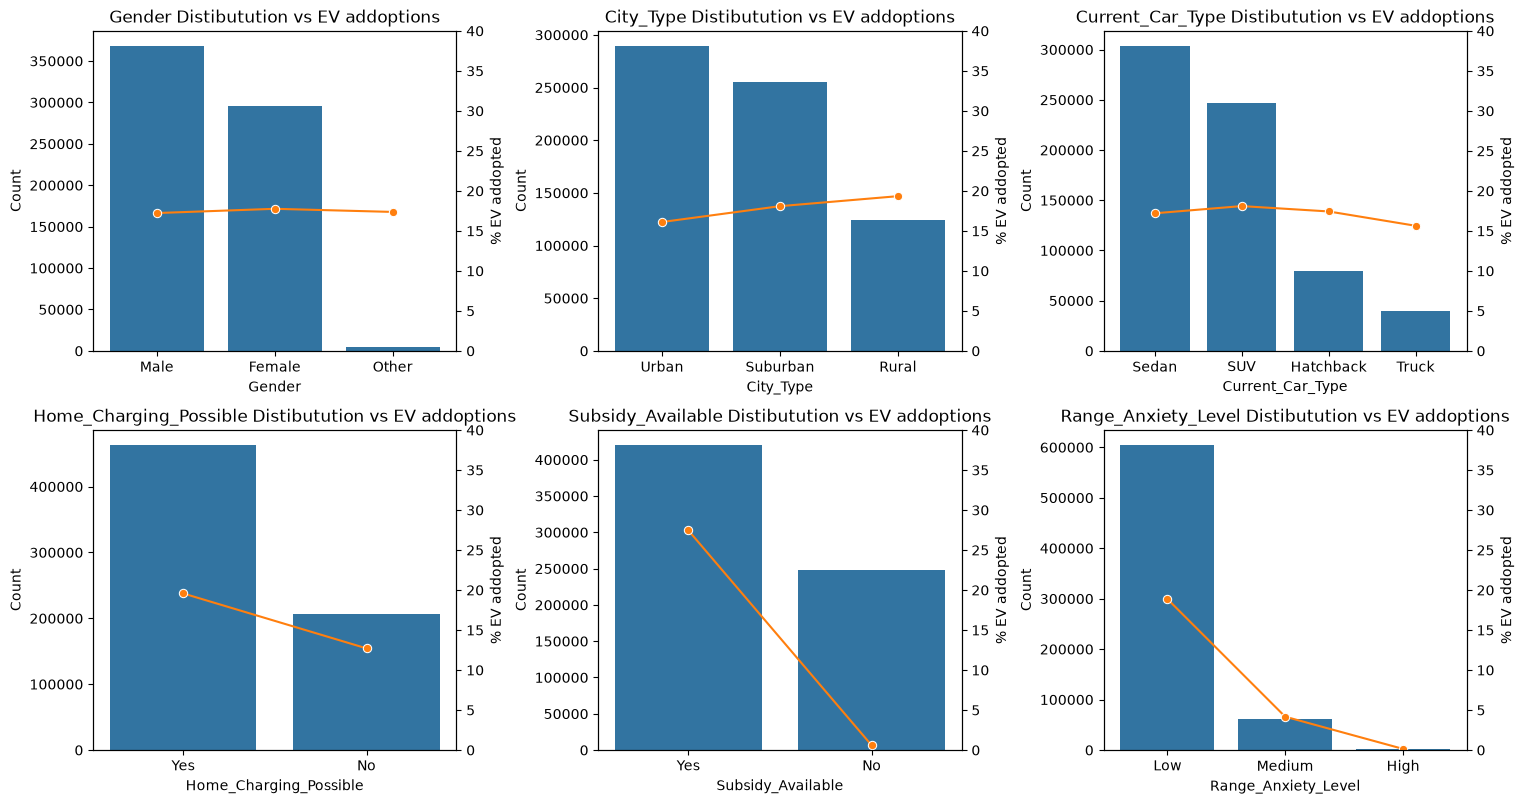

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(5.2*3, 4.2*2))
axes = axes.flatten()

for i, col in enumerate(train.drop(TARGET, axis=1).select_dtypes('str').columns.to_list()):
    ev_addoption = (train.groupby(col)['EV'].mean() * 100).round(2).reset_index()
    col_distibution = train[col].value_counts().reset_index()

    ax = axes[i]
    sns.barplot(data=col_distibution, x=col, y='count', color=BAR_COLOR, ax=ax)
    ax.set_ylabel('Count')

    ax = ax.twinx()
    sns.lineplot(data=ev_addoption, x=col, y='EV', color=LINE_COLOR, ax=ax, marker='o')
    ax.set_ylabel('% EV addopted')
    ax.set_ylim(0, 40)

    plt.title(f'{col} Distibutution vs EV addoptions')

plt.tight_layout(pad=2.0, w_pad=.8, h_pad=1.0)
plt.show()
    

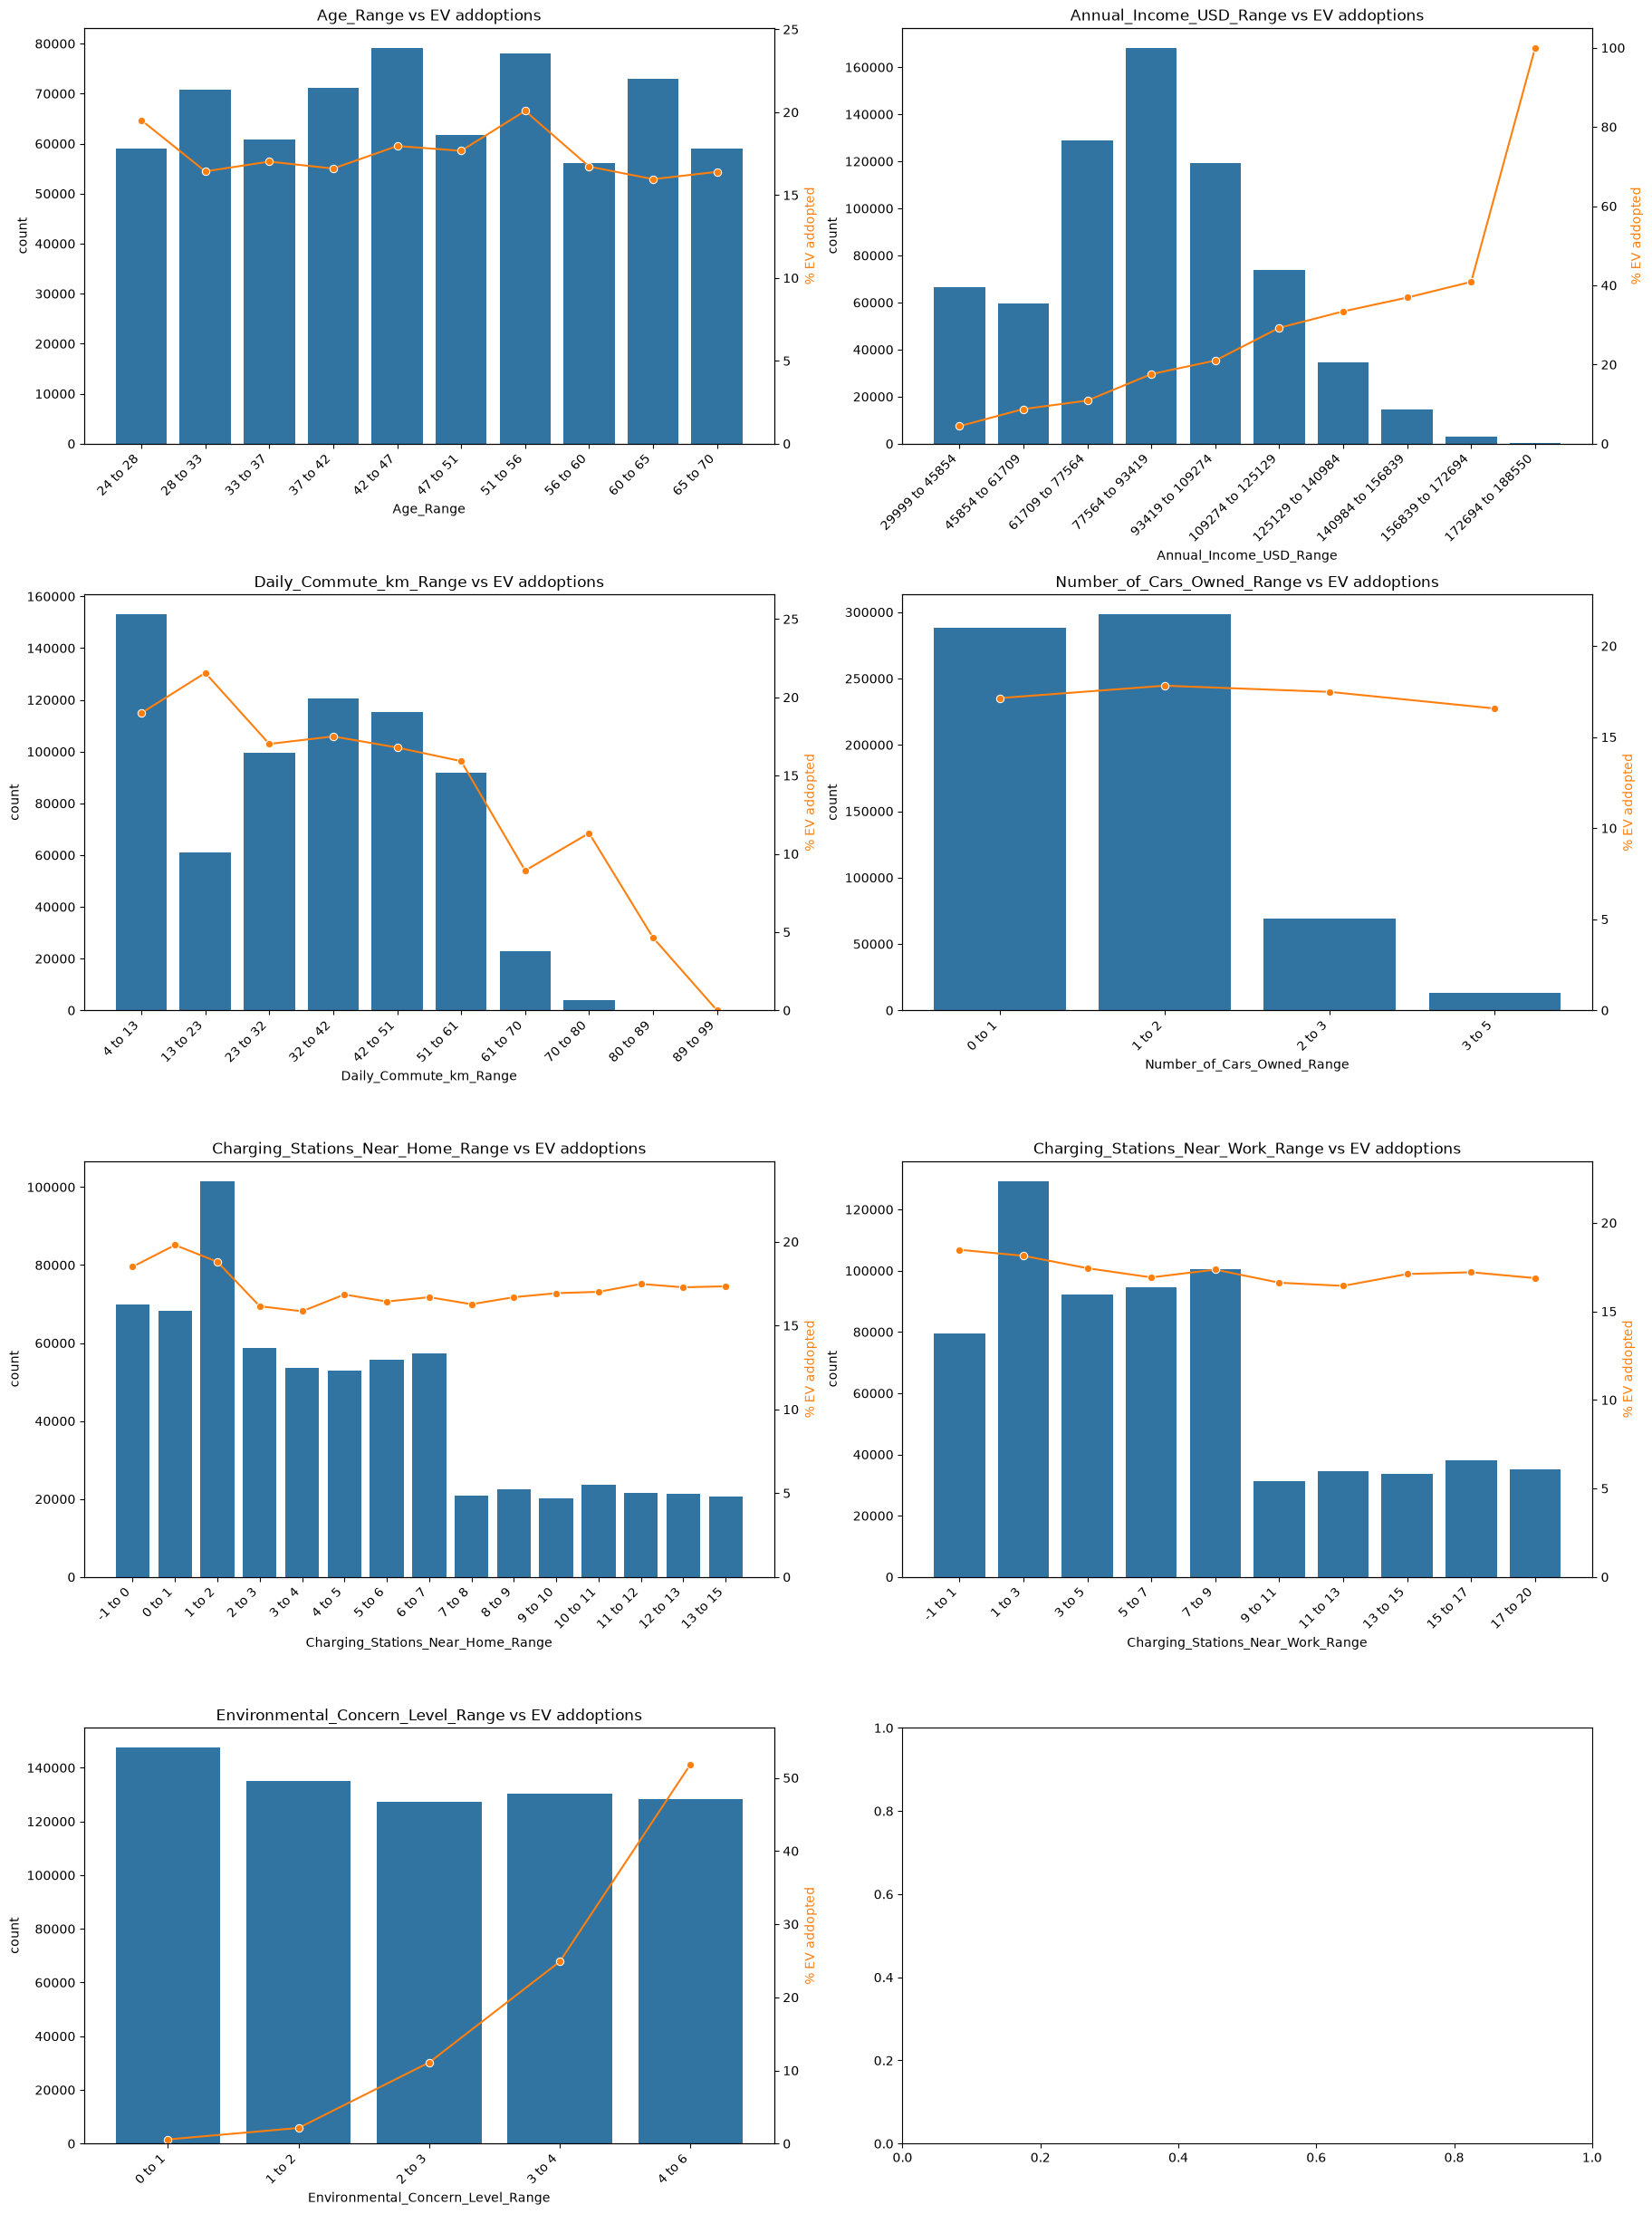

In [6]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(6.2*3, 6.2*4))
axes = axes.flatten()

for i, col in enumerate(train.drop(['EV', 'id'], axis=1).select_dtypes('number').columns.to_list()):
    col_range_name = f'{col}_Range'
    min_val, max_val = int(overview[overview['feature']==col]['min'].iloc[0]), int(overview[overview['feature']==col]['max'].iloc[0])
    unique = int(overview[overview['feature']==col]['unique'].iloc[0])
    
    bins = np.linspace(min_val-1, max_val+1, min(unique, 10 if unique>15 else unique)+1, dtype=int)
    labels = [f'{bins[i-1]} to {bins[i]}' for i in range(1, len(bins))]
    temp = train[[col, 'EV']]
    temp[col_range_name] = pd.cut(train[col], bins=bins, labels=labels)
    range_df = temp[col_range_name].value_counts(sort=False).reset_index()
    ev_addoption = (temp.groupby(col_range_name)['EV'].mean() * 100).round(2).reset_index()

    # print(col, min_val, max_val, unique, ev_addoption['EV'].max())
    assert range_df['count'].sum() == train[col].count()
    assert  np.array_equal(range_df[col_range_name], ev_addoption[col_range_name])

    ax = axes[i]
    sns.barplot(data = range_df, x=col_range_name, y='count', color=BAR_COLOR, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    ax = ax.twinx()
    sns.lineplot(data=ev_addoption, x=col_range_name, y='EV', color=LINE_COLOR, ax=ax, marker='o')
    ax.set_ylim(0, ev_addoption['EV'].max()+5)
    ax.set_ylabel('% EV addopted', color=LINE_COLOR)

    plt.title(f'{col_range_name} vs EV addoptions')

plt.tight_layout(pad=2.0, w_pad=.8, h_pad=1.0)
plt.show()
    

In [7]:
train.groupby('Environmental_Concern_Level')['EV'].value_counts(normalize=True).reset_index()

,Environmental_Concern_Level,EV,proportion
0,1.0,0,0.994345
1,1.0,1,0.005655
2,2.0,0,0.978621
3,2.0,1,0.021379
4,3.0,0,0.889078
5,3.0,1,0.110922
6,4.0,0,0.751152
7,4.0,1,0.248848
8,5.0,1,0.518287
9,5.0,0,0.481713
